In [ ]:
import numpy as np
import pandas as pd

from match3.game.level import Level, Objective, ObjectiveType
from match3.players.random_player import RandomPlayer
from match3.simulation.simulator import simulate_games

import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
%matplotlib inline

In [3]:
GOAL_RANGE = np.arange(3,52,3)
MOVE_BUDGET = 20
NUM_GAMES = 500

print(f"Simulating {NUM_GAMES} games for each goal in {GOAL_RANGE} with a move budget of {MOVE_BUDGET}...")
print(f"Total number of games to simulate: {len(GOAL_RANGE) * NUM_GAMES}")

Simulating 500 games for each goal in [ 3  6  9 12 15 18 21 24 27 30 33 36 39 42 45 48 51] with a move budget of 20...
Total number of games to simulate: 8500


In [4]:
rng = np.random.default_rng(42)
player = RandomPlayer(rng)

In [5]:
results_dict = {}

for goal in GOAL_RANGE:
    level = Level(
        name=f"Collect {goal} Red Candies",
        moves=MOVE_BUDGET,
        objective=Objective(
            type=ObjectiveType.COLLECT,
            target=int(goal),
            candy_type=0,
        ),
    )

    rng = np.random.default_rng(42 + int(goal))
    player = RandomPlayer(rng)

    results = simulate_games(
        level,
        player,
        n_games=NUM_GAMES,
        rng=rng,
    )

    wins = sum(result.won for result in results)

    win_rate = wins / NUM_GAMES

    lower, upper = proportion_confint(
        count=wins,
        nobs=NUM_GAMES,
        alpha=0.05,
        method="wilson",
    )

    results_dict[int(goal)] = {
        "win_rate": win_rate,
        "lower": lower,
        "upper": upper,
    }

In [6]:
results_df = pd.DataFrame.from_dict(
    results_dict,
    orient="index",
)

results_df.index.name = "target"
results_df = results_df.reset_index()

results_df

,target,win_rate,lower,upper
0,3,0.996,9.855343e-01,0.998902
1,6,0.996,9.855343e-01,0.998902
2,9,0.966,9.462286e-01,0.978665
3,12,0.878,8.463953e-01,0.903841
4,15,0.608,5.645405e-01,0.649813
5,18,0.410,3.677351e-01,0.453637
6,21,0.218,1.840337e-01,0.256266
7,24,0.098,7.492392e-02,0.127206
8,27,0.044,2.923396e-02,0.065719
9,30,0.014,6.797790e-03,0.028613


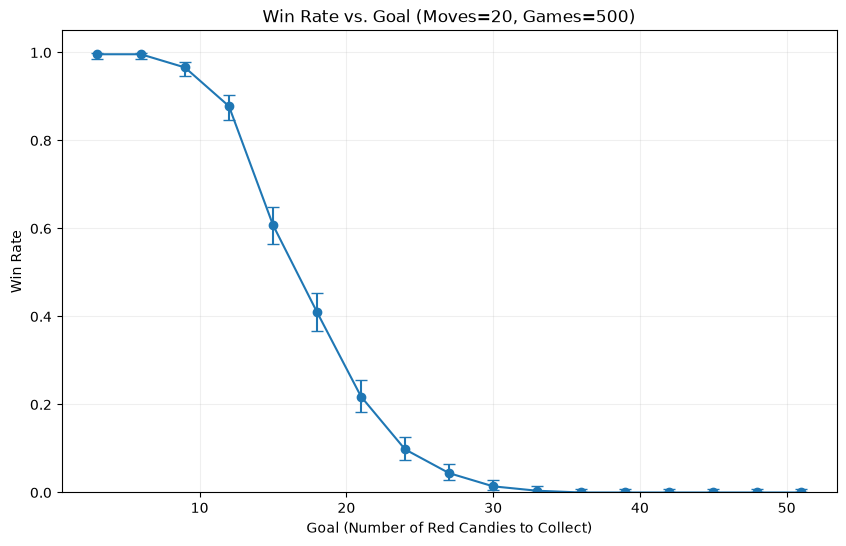

In [16]:
x = results_df["target"]
y = results_df["win_rate"]

lower_error = np.clip(y - results_df["lower"],0, None)
upper_error = results_df["upper"] - y

plt.figure(figsize=(10, 6))

plt.errorbar(
    x,
    y,
    yerr=[lower_error, upper_error],
    fmt="-o",
    capsize=4,
)

plt.xlabel("Goal (Number of Red Candies to Collect)")
plt.ylabel("Win Rate")
plt.title(
    f"Win Rate vs. Goal "
    f"(Moves={MOVE_BUDGET}, Games={NUM_GAMES})"
)

plt.ylim(0, 1.05)
plt.grid(alpha=0.2)

plt.show()

*Results*

Obviously it's pretty clear that increasing the goal but keeping the move budget constant reduces the chance of success, degrading down to an impossibility.

The curve is pretty steep, showing how small increases in the goal can have large increases in difficulty.

Error bars show 95% Wilson interval